In [20]:
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from empiricaldist import Cdf
from utils import decorate

sns.set_style('darkgrid')

## 12.1 Penguin Data

In [9]:
df = pd.read_csv('data/penguins_raw.csv').dropna(subset=['Body Mass (g)'])
df['Species2'] = df['Species'].apply(lambda species: species.split()[0])
df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments,Species2
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.,Adelie
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN,Adelie
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN,Adelie
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN,Adelie
5,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A2,Yes,2007-11-16,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805,NaN,Adelie


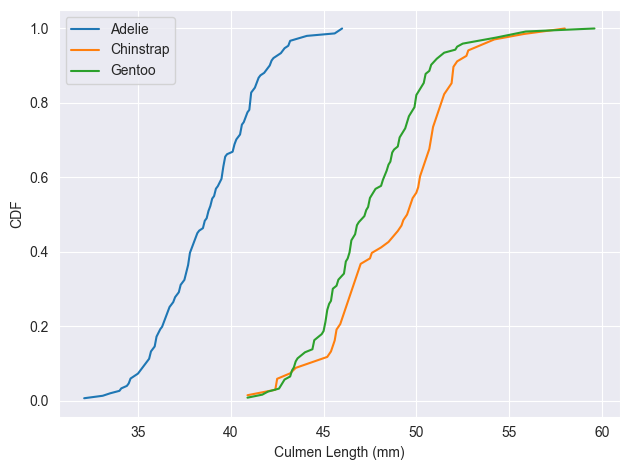

In [16]:
def make_cdf_map(df, colname, by='Species2'):
    cdf_map = {}
    grouped = df.groupby(by)[colname]
    for species, group in grouped:
        cdf_map[species] = Cdf.from_seq(group, name=species)
    return cdf_map


def plot_cdfs(df, colname, by='Species2'):
    """Make a CDF for each species.
    
    df: DataFrame
    colname: string column name
    by: string column name

    returns: dictionary from species name to Cdf
    """
    cdf_map = make_cdf_map(df, colname, by)
    
    for species, cdf in cdf_map.items():
        cdf.plot(label=species, marker='')
    
    decorate(xlabel=colname, ylabel='CDF')

plot_cdfs(df, 'Culmen Length (mm)')

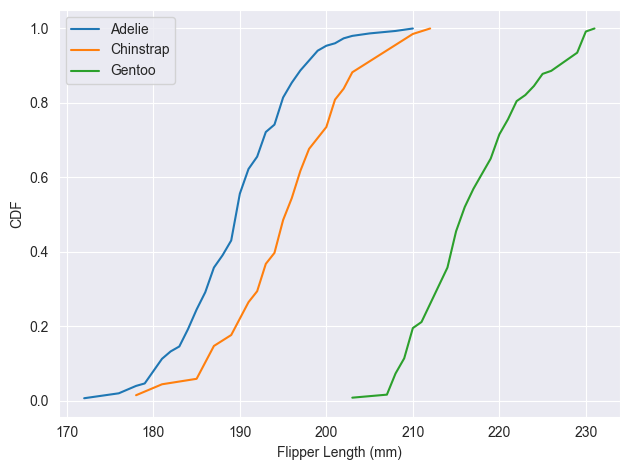

In [17]:
 plot_cdfs(df, 'Flipper Length (mm)')

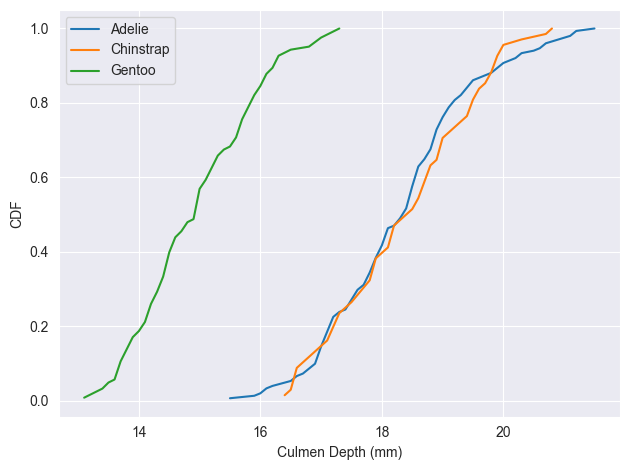

In [18]:
plot_cdfs(df, 'Culmen Depth (mm)')

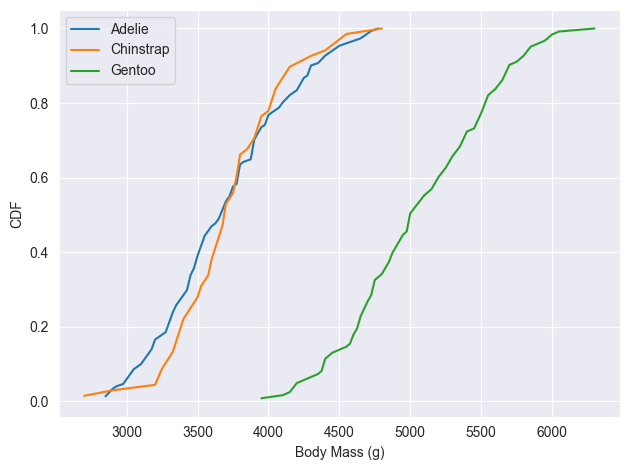

In [19]:
plot_cdfs(df, 'Body Mass (g)')

## 12.2 Normal Models

In [ ]:
def make_norm_map(df, colname, by='Species2'):
    norm_map = {}
    grouped = df.groupby(by)[colname]
    for species, group in grouped:
        mean = group.mean()
        std = group.std()
        norm_map[species] = norm(loc=mean, scale=std)
    return norm_map

flipper_map = make_norm_map(df, 'Flipper Length (mm)')